In [ ]:
import os
#from langchain import OpenAI, LLMChain, PromptTemplate
#from langchain.llms import HuggingFaceHub
import pandas as pd
import re
import time
import pandas as pd
from tqdm import tqdm

tqdm.pandas()

In [ ]:
df= pd.read_csv("aft.csv")
df.head()

,atu_id,tale_title,provenance,notes,source,text,data_source,date_obtained
0,910B,The Highlander Takes Three Advices from the En...,Scotland,NaN,"Cuthbert Bede [pseudonym for Edward Bradley], ...",In one of the glens of Cantire there lived a y...,Ashliman's Folktexts,2021-03-10
1,910B,The Prince Who Acquired Wisdom,India,NaN,"Cecil Henry Bompas, Folklore of the Santal Par...",There was once a raja who had an only son and ...,Ashliman's Folktexts,2021-03-10
2,910B,The Three Admonitions,Italy,NaN,"Thomas Frederick Crane, Italian Popular Tales,...",A man once left his country to go to foreign p...,Ashliman's Folktexts,2021-03-10
3,910B,The Three Advices,Ireland,The same story is found in The Rural Repositor...,"T. Crofton Croker, 'The Three Advices: An Iris...",The stories current among the Irish peasantry ...,Ashliman's Folktexts,2021-03-10
4,910B,The Three Advices Which the King with the Red ...,Ireland,NaN,"Patrick Kennedy, Legendary Fictions of the Iri...","The name of the young chief was Illan, called ...",Ashliman's Folktexts,2021-03-10


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1518 entries, 0 to 1517
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   atu_id         1518 non-null   object
 1   tale_title     1518 non-null   object
 2   provenance     1502 non-null   object
 3   notes          831 non-null    object
 4   source         1336 non-null   object
 5   text           1518 non-null   object
 6   data_source    1518 non-null   object
 7   date_obtained  1518 non-null   object
dtypes: object(8)
memory usage: 95.0+ KB


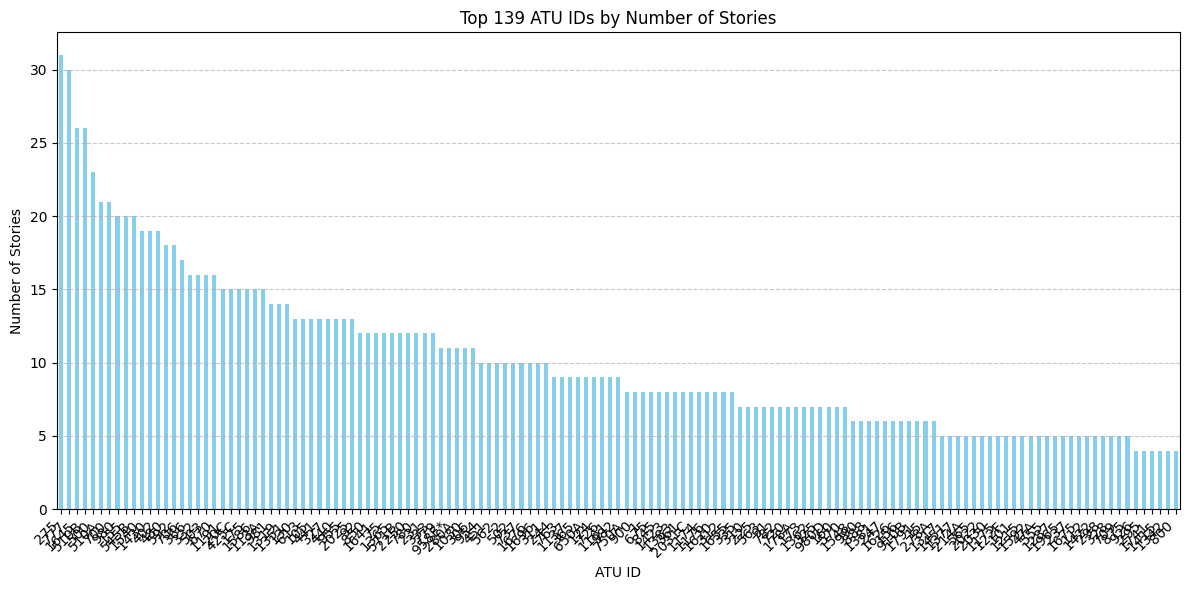

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# df = pd.read_csv("your_file.csv")

atu_counts = df['atu_id'].value_counts().sort_values(ascending=False)

top_n = 139
plt.figure(figsize=(12, 6))
atu_counts.head(top_n).plot(kind='bar', color='skyblue')

plt.title(f'Top {top_n} ATU IDs by Number of Stories')
plt.xlabel('ATU ID')
plt.ylabel('Number of Stories')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
under_limit=0
for text in df['text']:
    word_count = len(text.split())
    if word_count < 5461:
        under_limit += 1

percentage_under_6000 = (under_limit / len(df['text'])) * 100
print(f"{percentage_under_6000:.2f}% of texts have fewer than 6000 words.")

99.67% of texts have fewer than 6000 words.


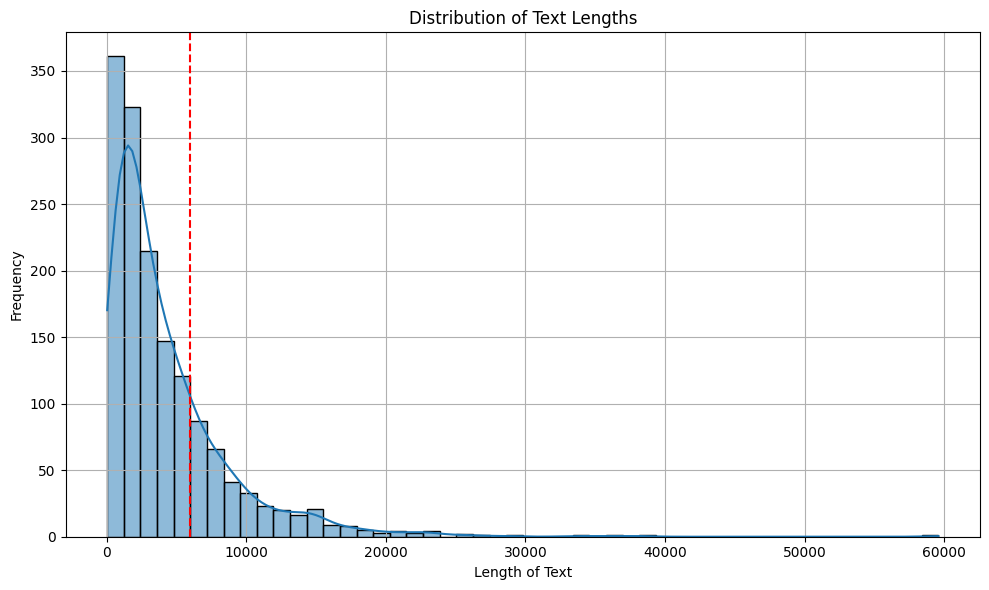

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df['text_length'] = df['text'].str.len()

plt.figure(figsize=(10, 6))
sns.histplot(df['text_length'], bins=50, kde=True)
plt.title('Distribution of Text Lengths')
plt.xlabel('Length of Text')
plt.ylabel('Frequency')
plt.axvline(x=6000, color='red', linestyle='--', label='6000 limit')

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1518 entries, 0 to 1517
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   atu_id         1518 non-null   object
 1   tale_title     1518 non-null   object
 2   provenance     1502 non-null   object
 3   notes          831 non-null    object
 4   source         1336 non-null   object
 5   text           1518 non-null   object
 6   data_source    1518 non-null   object
 7   date_obtained  1518 non-null   object
dtypes: object(8)
memory usage: 95.0+ KB


In [ ]:
df = df.dropna(subset=['source'])

In [ ]:
df.head(20)

,atu_id,tale_title,provenance,notes,source,text,data_source,date_obtained
0,910B,The Highlander Takes Three Advices from the En...,Scotland,NaN,"Cuthbert Bede [pseudonym for Edward Bradley], ...",In one of the glens of Cantire there lived a y...,Ashliman's Folktexts,2021-03-10
1,910B,The Prince Who Acquired Wisdom,India,NaN,"Cecil Henry Bompas, Folklore of the Santal Par...",There was once a raja who had an only son and ...,Ashliman's Folktexts,2021-03-10
2,910B,The Three Admonitions,Italy,NaN,"Thomas Frederick Crane, Italian Popular Tales,...",A man once left his country to go to foreign p...,Ashliman's Folktexts,2021-03-10
3,910B,The Three Advices,Ireland,The same story is found in The Rural Repositor...,"T. Crofton Croker, 'The Three Advices: An Iris...",The stories current among the Irish peasantry ...,Ashliman's Folktexts,2021-03-10
4,910B,The Three Advices Which the King with the Red ...,Ireland,NaN,"Patrick Kennedy, Legendary Fictions of the Iri...","The name of the young chief was Illan, called ...",Ashliman's Folktexts,2021-03-10
5,1430,Buttermilk Jack,NaN,"According to the narrator, this song was sung ...",Thomas Hughes The Scouring of the White Horse;...,"Oh mother, my buttermilk I will sell, And all ...",Ashliman's Folktexts,2021-03-10
6,1430,Day-Dreaming,The 1001 Nights,Note by Jacobs: I have given the story of the ...,"Joseph Jacobs, Europa's Fairy Book (New York a...",Now there was once a man at Bagdad who had sev...,Ashliman's Folktexts,2021-03-10
7,1430,Lazy Heinz,Jacob and Wilhelm Grimm,I have followed the Grimms' seventh and final ...,"Jacob and Wilhelm Grimm, 'Der faule Heinz,' Ki...","Heinz was lazy, and although he had nothing el...",Ashliman's Folktexts,2021-03-10
8,1430,Lean Lisa,Jacob and Wilhelm Grimm,I have followed the Grimms' seventh and final ...,"Jacob and Wilhelm Grimm, 'Die hagere Liese,' K...",Lean Lisa was not at all like Lazy Heinz and F...,Ashliman's Folktexts,2021-03-10
9,1430,Sheik Chilli,"India, Alice Elizabeth Dracott",NaN,"Alice Elizabeth Dracott, Simla Village Tales; ...",The hero of this story was one day walking alo...,Ashliman's Folktexts,2021-03-10


In [ ]:
df["atu_id"].value_counts().sort_index()

,count
atu_id,
1,8
101,5
103,2
105,13
112,5
...,...
980,19
980D,6
981,14


In [ ]:
df_temp = df.iloc[:300]
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300 entries, 0 to 362
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   atu_id         300 non-null    object
 1   tale_title     300 non-null    object
 2   provenance     296 non-null    object
 3   notes          191 non-null    object
 4   source         300 non-null    object
 5   text           300 non-null    object
 6   data_source    300 non-null    object
 7   date_obtained  300 non-null    object
dtypes: object(8)
memory usage: 21.1+ KB


In [ ]:
df_temp["atu_id"].value_counts()

,count
atu_id,
510B,22
1430,18
402,18
366,16
113A,15
425C,15
2025,13
231,12
850,11


In [ ]:
df[df["atu_id"]=="327"]['text'][636]

"Next to a great forest there lived a poor woodcutter with his wife and his two children. The boy's name was Hansel and the girl's name was Gretel. He had but little to eat, and once, when a great famine came to the land, he could no longer provide even their daily bread. One evening as he was lying in bed worrying about his problems, he sighed and said to his wife, 'What is to become of us? How can we feed our children when we have nothing for ourselves?' 'Man, do you know what?' answered the woman. 'Early tomorrow morning we will take the two children out into the thickest part of the woods, make a fire for them, and give each of them a little piece of bread, then leave them by themselves and go off to our work. They will not find their way back home, and we will be rid of them.' 'No, woman,' said the man. 'I will not do that. How could I bring myself to abandon my own children alone in the woods? Wild animals would soon come and tear them to pieces.' 'Oh, you fool,' she said, 'then 

In [ ]:
story= df[df["atu_id"]=="327"]['text'][636]

In [ ]:
story = filtered_df['text'][0]

In [ ]:
relationship_extraction_prompt_template = """
Given the following folktale, extract key motifs as a list of short, general phrases (e.g., ‘magical helper aids,’ ‘journey undertaken,’ ‘reward earned’). Avoid using synonyms with backslashes (e.g., ‘scarcity strikes,’ not ‘famine/scarcity’). Add slight detail for clarity, but keep phrases general and applicable across stories, avoiding specific names or objects.
Folktale: {text}

Motifs:
"""

import google.generativeai as genai


genai.configure(api_key="...")
model = genai.GenerativeModel("gemini-2.0-flash")

filled_prompt = relationship_extraction_prompt_template.format(text=story)
response = model.generate_content(filled_prompt)
response.text

'*   Impoverishment/Hardship Strikes\n*   Abandonment of Children Threatened\n*   Child Ingenuity to Avoid Harm\n*   Return Home Success\n*   Repeated Attempt to Abandon\n*   Loss of Prepared Escape Route\n*   Shelter Found in Unusual Place\n*   False Kindness Conceals Danger\n*   Captivity of a Child\n*   Sibling Solidarity Aiding Survival\n*   Evil Villain Deceived\n*   Villain Meets Fitting End\n*   Discovery of Wealth/Treasure\n*   Final Return Home\n*   Happily Ever After\n'

In [ ]:
import sys
import google.generativeai as genai

relationship_extraction_prompt_template = """
Given the following folktale, extract key motifs as a list of short, general phrases (e.g., ‘magical helper aids,’ ‘journey undertaken,’ ‘reward earned’). Avoid using synonyms with backslashes (e.g., ‘scarcity strikes,’ not ‘famine/scarcity’). Add slight detail for clarity, but keep phrases general and applicable across stories, avoiding specific names or objects.
Folktale: {text}

Motifs:
"""
import google.api_core.exceptions
api_keys = [
    "...",
    "...",
    "..."
]

def extract_relationships(story, attempt=0):
    if attempt >= len(api_keys):
        raise Exception("All API keys exhausted. Saving results so far and aborting.")

    try:
        genai.configure(api_key=api_keys[attempt])
        model = genai.GenerativeModel("gemini-2.0-flash")
        filled_prompt = relationship_extraction_prompt_template.format(text=story)
        response = model.generate_content(filled_prompt)
        return response

    except google.api_core.exceptions.TooManyRequests as e:
        print(f"API key {attempt + 1} exceeded limits. Switching to key {attempt + 2 if attempt + 2 <= len(api_keys) else 'none'}...")
        return extract_relationships(story, attempt + 1)
    except Exception as e:
        print(f"Unexpected error with API key {attempt + 1}: {e}")
        return extract_relationships(story, attempt + 1)

def apply_extraction(df):
    try:
       
        df['extracted_motifs'] = df['text'].progress_apply(extract_relationships)
        print("Extraction complete.")
        df.to_csv('full_folktale_results.csv', index=False)
        print("Full results saved to 'full_folktale_results.csv'.")
    except Exception as e:
        if "All API keys exhausted" in str(e):
            print("All API keys exhausted. Saving partial results...")
            df.to_csv('partial_folktale_results.csv', index=False)
            print("Partial results saved to 'partial_folktale_results.csv'. Exiting.")
            sys.exit(1)
        else:
            raise  

In [ ]:
apply_extraction(df)

  1%|▏         | 17/1336 [00:19<19:47,  1.11it/s]WARNING:tornado.access:429 POST /v1beta/models/gemini-2.0-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (127.0.0.1) 254.57ms


API key 1 exceeded limits. Switching to key 2...


  1%|▏         | 18/1336 [00:20<24:37,  1.12s/it]WARNING:tornado.access:429 POST /v1beta/models/gemini-2.0-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (127.0.0.1) 254.18ms


API key 1 exceeded limits. Switching to key 2...


  1%|▏         | 19/1336 [00:21<24:48,  1.13s/it]WARNING:tornado.access:429 POST /v1beta/models/gemini-2.0-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (127.0.0.1) 229.04ms


...

API key 1 exceeded limits. Switching to key 2...


100%|██████████| 1336/1336 [40:46<00:00,  1.48s/it]WARNING:tornado.access:429 POST /v1beta/models/gemini-2.0-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (127.0.0.1) 380.92ms


API key 1 exceeded limits. Switching to key 2...


100%|██████████| 1336/1336 [40:48<00:00,  1.83s/it]


Extraction complete.
Full results saved to 'full_folktale_results.csv'.


In [ ]:
df = pd.read_csv("full_folktale_results.csv")

def extract_text_from_response(response_str):
    text_match = re.search(r'"text": "([\s\S]*?)"', response_str)
    if text_match:
        return text_match.group(1)
    return None
df["extracted_motifs"] = df["extracted_motifs"].apply(
   extract_text_from_response
)

In [ ]:
df['extracted_motifs'][0]

'*   Difficult times motivate separation.\\n*   Departure begins a journey.\\n*   Work provides eventual success.\\n*   Wise advice is given in place of riches.\\n*   Adherence to advice yields rewards.\\n*   Innocence is proven by following advice.\\n*   Rash action averted by remembering advice.\\n*   Reunion leads to happiness.\\n*   Hidden riches revealed unexpectedly.\\n'

In [ ]:
df['extracted_motifs'][1331]

"Here's a list of motifs extracted from the folktale:\\n\\n*   Deceptive words spoken\\n*   Antagonist's vulnerability exploited\\n*   Failed expectation of easy reward\\n*   Disappointment after anticipation\\n*   Creature motivated by hunger\\n"

In [ ]:
#def extract_text(row):
#    return row.text

#df['text_motifs'] = df['extracted_motifs'].progress_apply(extract_text)
df['text_motifs'] = df['extracted_motifs']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1336 entries, 0 to 1335
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   atu_id            1336 non-null   object
 1   tale_title        1336 non-null   object
 2   provenance        1326 non-null   object
 3   notes             799 non-null    object
 4   source            1336 non-null   object
 5   text              1336 non-null   object
 6   data_source       1336 non-null   object
 7   date_obtained     1336 non-null   object
 8   extracted_motifs  1336 non-null   object
 9   text_motifs       1336 non-null   object
dtypes: object(10)
memory usage: 104.5+ KB


In [ ]:
df['text_motifs'][3]

'*   Period of hardship.\\n*   Journey undertaken for work.\\n*   Agreement with specific conditions.\\n*   Wise advice received as payment.\\n*   Disregarding wise advice leads to danger.\\n*   Eavesdropping reveals a plot.\\n*   Honesty rewarded.\\n*   Dishonesty exposed.\\n*   Material wealth gained.\\n*   Advice passed on to future generations.\\n'

In [ ]:
def clean_motifs(text):

    text = text.strip("[]").strip('"')
    lines = text.split("\\n")
    motifs = []
    for line in lines:
        if not line.strip() or "Here's a list" in line or "Here are" in line:
            continue
        cleaned_line = line.replace("*", "").strip()

        if ":" in cleaned_line:
            motif = cleaned_line.split(":", 1)[0].strip()
        else:
            motif = cleaned_line.strip()
        motif = motif.rstrip('.')
        if motif:
            motifs.append(motif)
    return motifs

df['motif_list'] = df['text_motifs'].apply(clean_motifs)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1336 entries, 0 to 1335
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   atu_id            1336 non-null   object
 1   tale_title        1336 non-null   object
 2   provenance        1326 non-null   object
 3   notes             799 non-null    object
 4   source            1336 non-null   object
 5   text              1336 non-null   object
 6   data_source       1336 non-null   object
 7   date_obtained     1336 non-null   object
 8   extracted_motifs  1336 non-null   object
 9   text_motifs       1336 non-null   object
 10  motif_list        1336 non-null   object
dtypes: object(11)
memory usage: 114.9+ KB


In [ ]:
df['motif_list']

,motif_list
0,"[Difficult times motivate separation, Departur..."
1,"[Disregard for parental advice, Journey undert..."
2,"[Departure from homeland, Service in a foreign..."
3,"[Period of hardship, Journey undertaken for wo..."
4,"[Testing of advice/wisdom, Loss through foolis..."
...,...
1331,"[Deceptive words spoken, Antagonist's vulnerab..."
1332,"[Threat used for compliance, Animal eavesdropp..."
1333,"[Threat used to control, Deception fails, Disa..."
1334,"[Threat used to enforce obedience, Deceptive p..."


In [ ]:
index_of_stories_with_zero_motif=[]
for i in range(len(df)):
  l = len(df["motif_list"].iloc[i])
  if l == 0:
    index_of_stories_with_zero_motif.append(i)
print(len(index_of_stories_with_zero_motif))
df = df.drop(index_of_stories_with_zero_motif)

1


In [ ]:
print(df['motif_list'].apply(len).describe())
print("zero motifs:")
print(len(df[df['motif_list'].apply(len) == 0]))

count    1335.000000
mean        7.537079
std         2.479891
min         1.000000
25%         6.000000
50%         7.000000
75%         9.000000
max        21.000000
Name: motif_list, dtype: float64
zero motifs:
0


In [ ]:
len(list(set([motif for motif_list in df['motif_list'] for motif in motif_list])))

8837

In [ ]:
import nltk
from nltk.corpus import wordnet
nltk.download('wordnet')
nltk.download('omw-1.4')

def get_canonical_word(word):
    synsets = wordnet.synsets(word)
    if synsets:
        return synsets[0].lemmas()[0].name().lower()
    return word.lower()

def standardize_motif(motif):
    words = motif.lower().split()
    return " ".join([get_canonical_word(word) for word in words])

df['motif_list_standardized'] = df['motif_list'].progress_apply(
    lambda motifs: [standardize_motif(m) for m in motifs]
)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
100%|██████████| 1335/1335 [00:05<00:00, 245.44it/s] 


In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer('all-MiniLM-L6-v2')


all_motifs = list(set([motif for motif_list in df['motif_list'] for motif in motif_list]))

motif_embeddings = model.encode(all_motifs, show_progress_bar=True)

embedding_dict = dict(zip(all_motifs, motif_embeddings))

df['motif_embeddings'] = df['motif_list'].apply(lambda motifs: [embedding_dict[m] for m in motifs])

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/277 [00:00<?, ?it/s]

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_distances
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics.pairwise import cosine_similarity

data = {'atu_id': [], 'embedding': [], 'sentence': []}
for idx, row in df.iterrows():
    atu = row['atu_id']
    embeddings = row['motif_embeddings']
    sentences =row['motif_list'][0:len(embeddings)]

    for emb, sent in zip(embeddings, sentences):
        data['atu_id'].append(atu)
        data['embedding'].append(emb)
        data['sentence'].append(sent)

motif_df = pd.DataFrame(data)


embedding_matrix = np.array(motif_df['embedding'].tolist())
###using DBSCAN clusterin
clustering = DBSCAN(eps=0.1, min_samples=2, metric='cosine').fit(embedding_matrix)
motif_df['cluster'] = clustering.labels_
cluster_atu_counts = motif_df.groupby('cluster')['atu_id'].nunique().reset_index()
cluster_atu_counts = cluster_atu_counts[cluster_atu_counts['cluster'] != -1]
k = 10
top_k_clusters = cluster_atu_counts.nlargest(k, 'atu_id')


print("Top k motifs across ATU indexes:")
for _, row in top_k_clusters.iterrows():
    cluster_id = row['cluster']
    num_atu = row['atu_id']
    cluster_data = motif_df[motif_df['cluster'] == cluster_id]

    cluster_embeddings = np.array(cluster_data['embedding'].tolist())
    centroid = np.mean(cluster_embeddings, axis=0)
    similarities = cosine_similarity([centroid], cluster_embeddings)[0]
    cluster_temp = pd.DataFrame({
        'similarity': similarities,
        'sentence': cluster_data['sentence'],
        'atu_id': cluster_data['atu_id']
    })

    cluster_temp = cluster_temp.sort_values('similarity', ascending=False)
    selected_sentences = []
    selected_atu_ids = set()
    for _, temp_row in cluster_temp.iterrows():
        if temp_row['atu_id'] not in selected_atu_ids:
            selected_sentences.append((temp_row['sentence'], temp_row['atu_id']))
            selected_atu_ids.add(temp_row['atu_id'])
        if len(selected_sentences) == 3:
            break
    representative_sentences = [sent for sent, _ in selected_sentences]
    representative_sentences_atu = [atu for _, atu in selected_sentences]

    print(f"\nCluster {cluster_id}: Appears in {num_atu} ATU indexes")
    print("Representative sentences:")
    for i, (sent, atu) in enumerate(zip(representative_sentences, representative_sentences_atu), 1):
        print(f"  {i}. {sent} ----Index: {atu}")

Top k motifs across ATU indexes:

Cluster 71: Appears in 46 ATU indexes
Representative sentences:
  1. Deception employed ----Index: 402
  2. Deception employed ----Index: 850
  3. Deception employed ----Index: 1678

Cluster 62: Appears in 35 ATU indexes
Representative sentences:
  1. Journey undertaken ----Index: 700
  2. Journey undertaken ----Index: 402
  3. Journey undertaken ----Index: 451

Cluster 19: Appears in 29 ATU indexes
Representative sentences:
  1. Moral lesson imparted ----Index: 1430
  2. Moral lesson imparted ----Index: 1558
  3. Moral lesson imparted ----Index: 926

Cluster 57: Appears in 24 ATU indexes
Representative sentences:
  1. Trickery/Deception employed ----Index: 1383
  2. Trickery/deception employed ----Index: 1175
  3. Deception/Trickery ----Index: 402

Cluster 97: Appears in 21 ATU indexes
Representative sentences:
  1. Encounter with a supernatural being ----Index: 1157
  2. Encounter with a supernatural being ----Index: 592
  3. Encounter with supernatu

In [ ]:
from itertools import combinations
def compare_motifs_across_atu(df):
    results = []

    grouped = df.groupby("atu_id")

    for (atu1, group1), (atu2, group2) in combinations(grouped, 2):

        motifs1 = [motif for motif_list in group1["motif_list"] for motif in motif_list]
        embeddings1 = [emb for emb_list in group1["motif_embeddings"] for emb in emb_list]
        motifs2 = [motif for motif_list in group2["motif_list"] for motif in motif_list]
        embeddings2 = [emb for emb_list in group2["motif_embeddings"] for emb in emb_list]

        if len(motifs1) != len(embeddings1) or len(motifs2) != len(embeddings2):
            print(f"Warning: Mismatch in {atu1} or {atu2}: motifs vs embeddings")
            continue

        try:
            sentence_embeddings1 = np.array(embeddings1)
            sentence_embeddings2 = np.array(embeddings2)
        except ValueError as e:
            print(f"Error stacking embeddings for {atu1} vs {atu2}: {e}")
            continue

        similarity_matrix = cosine_similarity(sentence_embeddings1, sentence_embeddings2)


        while True:
            max_sim_idx = np.unravel_index(np.argmax(similarity_matrix), similarity_matrix.shape)
            sentence1_idx, sentence2_idx = max_sim_idx
            max_similarity = similarity_matrix[sentence1_idx, sentence2_idx]


            if max_similarity < 0.1:
                break

            motif1 = motifs1[sentence1_idx]
            motif2 = motifs2[sentence2_idx]

            if (motif1 == motif2):
                similarity_matrix[sentence1_idx, sentence2_idx] = -1
                continue


            results.append({
                "ATU_Index_1": atu1,
                "ATU_Index_2": atu2,
                "motif1": motif1,
                "motif2": motif2,
                "Similarity": max_similarity
            })
            break


    results_df = pd.DataFrame(results)
    if not results_df.empty:
        results_df = results_df.sort_values(by="Similarity", ascending=False).reset_index(drop=True)

    return results_df
similarities_across_atu = compare_motifs_across_atu(df)
similarities_across_atu

,ATU_Index_1,ATU_Index_2,motif1,motif2,Similarity
0,1383,700,Return home,Return Home,1.000000
1,2031C,700,Return home,Return Home,1.000000
2,1176,700,Return home,Return Home,1.000000
3,306,954,Happily ever after,Happily Ever After,1.000000
4,954,955,Happily Ever After,Happily ever after,1.000000
...,...,...,...,...,...
13036,1558,2035,Deception employed,Causation drives the narrative,0.299710
13037,1730,2035,Deception employed for personal gain,Causation drives the narrative,0.298989
13038,2035,313,Causation drives the narrative,Deception through trickery,0.290657
13039,2035,779J*,Causation drives the narrative,Painful infliction as punishment,0.266306


In [ ]:
from sklearn.cluster import DBSCAN


dbscan = DBSCAN(eps=0.2, min_samples=2, metric='cosine')
motif_clusters = dbscan.fit_predict(motif_embeddings)

motif_cluster_df = pd.DataFrame({'motif': all_motifs, 'cluster': motif_clusters})

cluster_reps = motif_cluster_df[motif_cluster_df['cluster'] != -1].groupby('cluster')['motif'].first().to_dict()
motif_mapping = {}
for _, row in motif_cluster_df.iterrows():
    if row['cluster'] == -1:
        motif_mapping[row['motif']] = row['motif']
    else:
        motif_mapping[row['motif']] = cluster_reps[row['cluster']]


df['motif_list_clustered'] = df['motif_list'].apply(lambda motifs: [motif_mapping[m] for m in motifs])

In [ ]:
len(list(set([motif for motif_list in df['motif_list_clustered'] for motif in motif_list])))

5412

In [ ]:
df['motif_embeddings_clustered'] = df['motif_list_clustered'].apply(lambda motifs: [embedding_dict[m] for m in motifs])

In [ ]:
def compare_motifs_across_atu(df):
    results = []

    grouped = df.groupby("atu_id")

    for (atu1, group1), (atu2, group2) in combinations(grouped, 2):

        motifs1 = [motif for motif_list in group1["motif_list_clustered"] for motif in motif_list]
        embeddings1 = [emb for emb_list in group1["motif_embeddings_clustered"] for emb in emb_list]
        motifs2 = [motif for motif_list in group2["motif_list_clustered"] for motif in motif_list]
        embeddings2 = [emb for emb_list in group2["motif_embeddings_clustered"] for emb in emb_list]

        if len(motifs1) != len(embeddings1) or len(motifs2) != len(embeddings2):
            print(f"Warning: Mismatch in {atu1} or {atu2}: motifs vs embeddings")
            continue

        try:
            sentence_embeddings1 = np.array(embeddings1)
            sentence_embeddings2 = np.array(embeddings2)
        except ValueError as e:
            print(f"Error stacking embeddings for {atu1} vs {atu2}: {e}")
            continue

        similarity_matrix = cosine_similarity(sentence_embeddings1, sentence_embeddings2)


        while True:
            max_sim_idx = np.unravel_index(np.argmax(similarity_matrix), similarity_matrix.shape)
            sentence1_idx, sentence2_idx = max_sim_idx
            max_similarity = similarity_matrix[sentence1_idx, sentence2_idx]


            if max_similarity < 0.1:
                break

            motif1 = motifs1[sentence1_idx]
            motif2 = motifs2[sentence2_idx]

            if (motif1 == motif2):
                similarity_matrix[sentence1_idx, sentence2_idx] = -1
                continue


            results.append({
                "ATU_Index_1": atu1,
                "ATU_Index_2": atu2,
                "motif1": motif1,
                "motif2": motif2,
                "Similarity": max_similarity
            })
            break


    results_df = pd.DataFrame(results)
    if not results_df.empty:
        results_df = results_df.sort_values(by="Similarity", ascending=False).reset_index(drop=True)

    return results_df
similarities_across_atu = compare_motifs_across_atu(df)
similarities_across_atu

,ATU_Index_1,ATU_Index_2,motif1,motif2,Similarity
0,2034F,709,Shelter found during hardship,Shelter sought in unusual place,0.799942
1,2034F,503,Shelter found during hardship,Shelter sought in unusual place,0.799942
2,244,510B,Desire for power motivates actions,Desire motivates actions,0.799906
3,244,91,Desire for power motivates actions,Desire motivates actions,0.799906
4,1626,955,Deception planned within a group,Deception exposed at gathering,0.799819
...,...,...,...,...,...
13036,1548,2035,Ingredients added incrementally,Repetition with variation,0.269282
13037,2035,779J*,Causation drives the narrative,Painful infliction as punishment,0.266306
13038,1381D,2035,Punishment avoided,Causation drives the narrative,0.255189
13039,1558,2035,Hypocrisy exposed,Causation drives the narrative,0.247207


In [ ]:

df_exploded = df.explode('motif_list').rename(columns={'motif_list': 'motif'})

df_exploded = df_exploded.dropna(subset=['motif'])
motif_atu_distribution = (df_exploded.groupby('motif')['atu_id']
                         .agg(['nunique', 'unique', 'count'])
                         .reset_index()
                         .rename(columns={'nunique': 'num_atu_indexes',
                                          'unique': 'atu_indexes',
                                          'count': 'frequency'}))

motif_atu_distribution = motif_atu_distribution.sort_values(by='num_atu_indexes', ascending=False)

In [ ]:
widespread_motifs = motif_atu_distribution[motif_atu_distribution['num_atu_indexes'] > 1]

print("Motifs appearing in multiple ATU indexes:")
print(widespread_motifs.head(10))

Motifs appearing in multiple ATU indexes:
                          motif  num_atu_indexes  \
1524         Deception employed               46   
4142         Journey undertaken               32   
5777  Punishment fits the crime               20   
4598        Magical helper aids               17   
4929      Moral lesson imparted               14   
7866          Trickery employed               13   
1505        Deception attempted               13   
2384         Escape from danger               13   
7747      Transformation occurs               11   
6393        Reversal of fortune               11   

                                            atu_indexes  frequency  
1524  [402, 850, 1678, 1423, 1451, 2025, 926, 510B, ...         71  
4142  [402, 361, 451, 2031C, 20C, 1191, 1645, 122F, ...         38  
5777  [425C, 850, 451, 2025, 2031C, 311, 503, 105, 9...         26  
4598  [402, 510B, 592, 888, 480, 571B, 313, 500, 570...         32  
4929  [1430, 926, 1558, 231, 335, 105, 1

In [ ]:

df_exploded = df.explode('motif_list_clustered').rename(columns={'motif_list_clustered': 'motif'})

df_exploded = df_exploded.dropna(subset=['motif'])
motif_atu_distribution = (df_exploded.groupby('motif')['atu_id']
                         .agg(['nunique', 'unique', 'count'])
                         .reset_index()
                         .rename(columns={'nunique': 'num_atu_indexes',
                                          'unique': 'atu_indexes',
                                          'count': 'frequency'}))

motif_atu_distribution = motif_atu_distribution.sort_values(by='num_atu_indexes', ascending=False)
widespread_motifs = motif_atu_distribution[motif_atu_distribution['num_atu_indexes'] > 1]

print("Motifs appearing in multiple ATU indexes:")
print(widespread_motifs.head(20))

Motifs appearing in multiple ATU indexes:
                                            motif  num_atu_indexes  \
1022              Deception or trickery suspected              141   
3622           Punishment/consequence is received               56   
2566       Journey undertaken to distant location               47   
3039                        Moral lesson provided               43   
4564                  Task assigned is impossible               38   
2614          Kindness rewarded, cruelty punished               37   
3600                           Punishment avoided               34   
1969               Greed is ultimately unrewarded               31   
4858                     Trickster outwits victim               30   
282                            Animals as helpers               30   
2893                               Marital reward               28   
3543    Promise made with unforeseen consequences               27   
2745                  Loss of fortune experience

In [ ]:
def compute_mean_embedding(embeddings_list):
    if not embeddings_list:
        return np.nan
    return np.mean(np.vstack(embeddings_list), axis=0)

df['story_embedding_based_on_original_motifs'] = df['motif_embeddings'].apply(compute_mean_embedding)
df['story_embedding_based_on_clustered_motifs'] = df['motif_embeddings_clustered'].apply(compute_mean_embedding)

In [ ]:
atu_id_counts = df['atu_id'].value_counts()
atu_ids_repeated_more_than_5 = atu_id_counts[atu_id_counts.between(15, 18, inclusive="left")].index
temp_df = df[df['atu_id'].isin(atu_ids_repeated_more_than_5)]
temp_df['atu_id'].value_counts()

,count
atu_id,
706,17
366,16
332,16
670,16
20C,15
425C,15
503,15
1191,15
113A,15


In [ ]:
temp_df.head()

,atu_id,tale_title,provenance,notes,source,text,data_source,date_obtained,extracted_motifs,text_motifs,motif_list,motif_embeddings,motif_list_clustered,motif_embeddings_clustered,story_embedding_based_on_original_motifs,story_embedding_based_on_clustered_motifs
75,425C,Beauty and the Beast (Basque),Basque,Webster's source: Estefanella Hirigaray.,"Wentworth Webster, Basque Legends, 2nd edition...",As there are many in the world in its state no...,Ashliman's Folktexts,2021-03-10,Here's a list of motifs extracted from the fol...,Here's a list of motifs extracted from the fol...,"[Favoritism shown between siblings, Promise le...","[[0.032319587, 0.067364596, -0.0015852368, -0....","[Favoritism shown between siblings, Promise ma...","[[0.032319587, 0.067364596, -0.0015852368, -0....","[-0.05001781, 0.08893715, 0.010870356, -0.0032...","[-0.05273116, 0.08090586, 0.0012252475, -0.002..."
76,425C,Beauty and the Beast (Jacobs),Joseph Jacobs,NaN,"Joseph Jacobs, Europa's Fairy Book [also publi...",There was once a merchant that had three daugh...,Ashliman's Folktexts,2021-03-10,* Initial request made of a family member\n*...,* Initial request made of a family member\n*...,"[Initial request made of a family member, Prom...","[[-0.14547361, 0.06165924, -0.044862486, -0.05...","[Initial request made of a family member, Prom...","[[-0.14547361, 0.06165924, -0.044862486, -0.05...","[-0.042302385, 0.033943493, 0.020656288, 0.023...","[-0.057587285, 0.052068003, 0.0070275855, 0.01..."
77,425C,Beauty and the Horse,Denmark,Bay's sources for this collection: Svend Grund...,"J. Christian Bay, Danish Fairy and Folk Tales ...",There was once a merchant whose business was s...,Ashliman's Folktexts,2021-03-10,* Financial misfortune prompts a journey\n* ...,* Financial misfortune prompts a journey\n* ...,"[Financial misfortune prompts a journey, Unwit...","[[0.056062646, 0.056712296, 0.010297447, 0.092...","[Financial misfortune prompts a journey, Unwit...","[[0.056062646, 0.056712296, 0.010297447, 0.092...","[-0.03334503, 0.052928507, 0.036937587, 0.0508...","[-0.03906439, 0.069053225, 0.025178231, 0.0255..."
78,425C,Little Broomstick,Germany,Ludwig Bechstein (1801-1860) was Germany's mos...,"Ludwig Bechstein, 'Besenstielchen,' Deutsches ...",There was once a merchant who had three daught...,Ashliman's Folktexts,2021-03-10,* **Departure on a journey:** Individual lea...,* **Departure on a journey:** Individual lea...,"[Departure on a journey, Request for a gift, U...","[[0.08654809, -0.005902999, 0.0064456565, 0.04...","[Departure begins a journey, Unexpected gift r...","[[0.052630205, -0.030024702, 0.006122196, 0.04...","[-0.044902153, 0.065849744, 0.015703334, 0.019...","[-0.03648822, 0.06747169, 0.017966827, 0.02179..."
79,425C,Rose,Irish-American,"Newell's source: 'Obtained in Cambridge, Mass....","W. W. Newell, 'English Folk-Tales in America J...",Once it was necessary for him to go on a long ...,Ashliman's Folktexts,2021-03-10,* Quest initiated by request\n* Promise ma...,* Quest initiated by request\n* Promise ma...,"[Quest initiated by request, Promise made, dan...","[[-0.045849822, 0.05818762, -0.047489215, 0.00...","[Request initiates quest, Promise made, danger...","[[-0.07321856, 0.020368388, -0.037858818, -0.0...","[-0.041066825, 0.07519931, -0.010133312, 0.007...","[-0.0609002, 0.08207739, -0.010320267, 0.00417..."


In [ ]:
expanded_df = temp_df.explode(['motif_embeddings']).reset_index(drop=True)

In [ ]:
expanded_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1286 entries, 0 to 1285
Data columns (total 16 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   atu_id                                     1286 non-null   object
 1   tale_title                                 1286 non-null   object
 2   provenance                                 1275 non-null   object
 3   notes                                      597 non-null    object
 4   source                                     1286 non-null   object
 5   text                                       1286 non-null   object
 6   data_source                                1286 non-null   object
 7   date_obtained                              1286 non-null   object
 8   extracted_motifs                           1286 non-null   object
 9   text_motifs                                1286 non-null   object
 10  motif_list                          

In [ ]:
all_embeddings[1]

array([ 0.29884103,  0.01406781,  0.05904679, -0.02985258,  0.17168736,
        0.04032698, -0.35579827,  0.04946752,  0.04254576,  0.00796166,
       -0.19167179, -0.07187505, -0.05070083,  0.11709569, -0.01280826,
       -0.1177369 ,  0.28832456,  0.00785258, -0.01812705,  0.08020742,
       -0.00742199, -0.10081372,  0.06743049,  0.16265106,  0.23860814,
       -0.06782448,  0.1408507 ,  0.02330681, -0.02076293, -0.11871873,
        0.11254851,  0.06623243, -0.03336883,  0.03864135, -0.01706714,
        0.09056728, -0.0251517 , -0.00203757,  0.0087798 ,  0.05137379,
       -0.01095421, -0.00173138,  0.03717869,  0.00223088, -0.03365899,
       -0.00431509,  0.00204643, -0.08974069,  0.00941699, -0.10950044],
      dtype=float32)

In [ ]:
len(all_embeddings)

11718

<ipython-input-40-e8626de71aad>:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_map = plt.cm.get_cmap('tab20', len(unique_atu_indices))


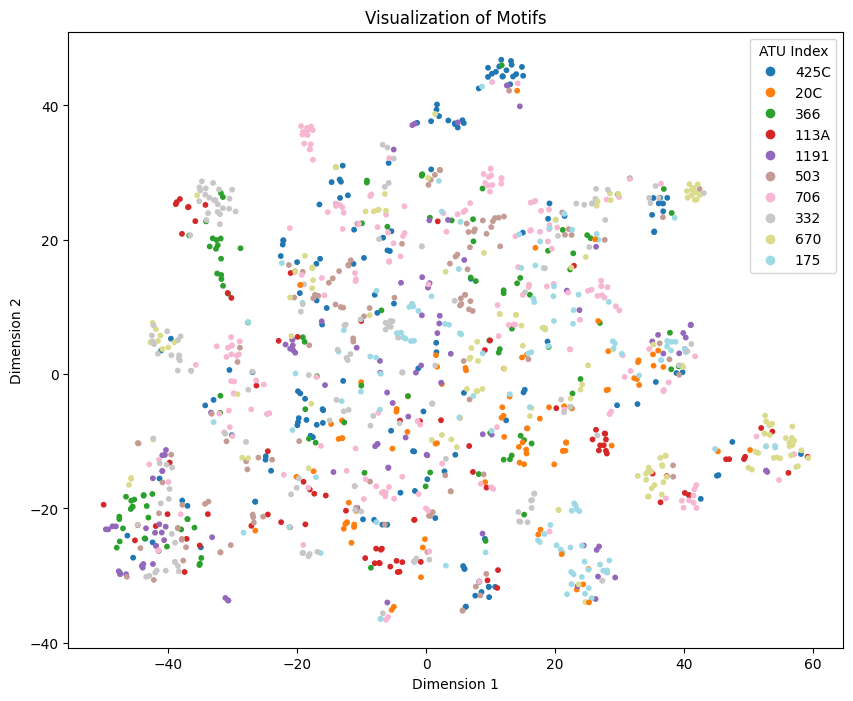

In [ ]:

#import mplcursors
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

atu_indices = []
for index, row in expanded_df.iterrows():
    atu_indices.append(row["atu_id"])

all_embeddings = np.vstack(expanded_df["motif_embeddings"].values)
#np.vstack(filtered_df["Sentence_Embeddings"].values)
from sklearn.decomposition import PCA
pca = PCA(n_components=50)
all_embeddings = pca.fit_transform(all_embeddings)

tsne = TSNE(n_components=2, random_state=42)
reduced_embeddings = tsne.fit_transform(all_embeddings)
#temp_df['TSNE_X'] = reduced_embeddings[:, 0]
#temp_df['TSNE_Y'] = reduced_embeddings[:, 1]


unique_atu_indices = expanded_df["atu_id"].unique()

colors_map = plt.cm.get_cmap('tab20', len(unique_atu_indices))

atu_color_dict = {atu: colors_map(i / len(unique_atu_indices)) for i, atu in enumerate(unique_atu_indices)}


point_colors = [atu_color_dict[atu] for atu in atu_indices]


plt.figure(figsize=(10, 8))
scatter = plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=point_colors,  s=10)

legend_patches = [plt.Line2D([0], [0], marker='o', color='w', markersize=8,
                             markerfacecolor=atu_color_dict[atu], label=f"{atu}")
                  for atu in unique_atu_indices]
plt.legend(handles=legend_patches, title="ATU Index", loc="best")


plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.title("Visualization of Motifs")

plt.show()


<ipython-input-42-4b78ca4326a2>:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_map = plt.cm.get_cmap('tab20', len(unique_atu_indices))


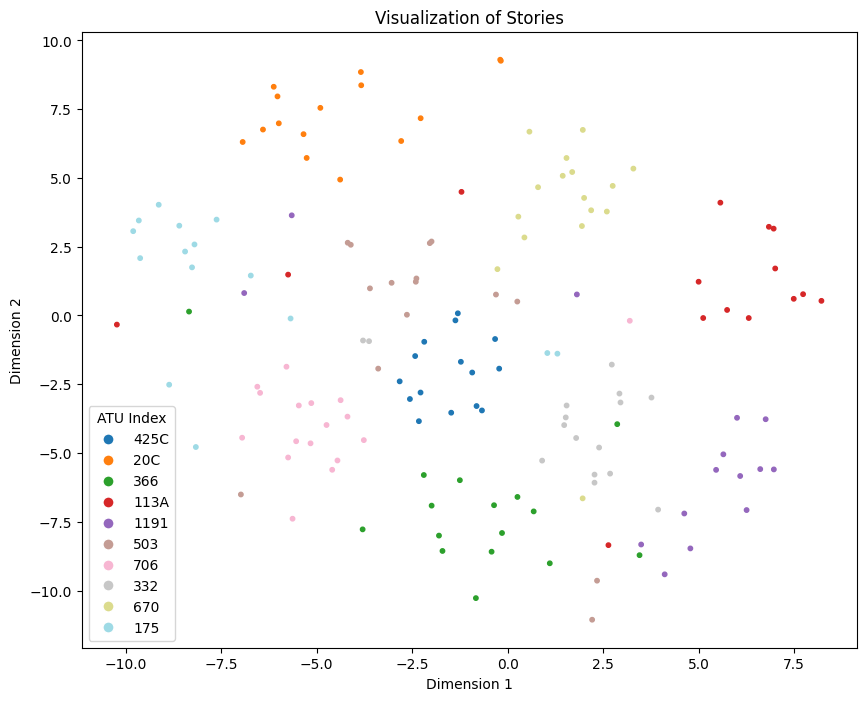

In [ ]:

#import mplcursors
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

atu_indices = []
for index, row in temp_df.iterrows():
    atu_indices.append(row["atu_id"])

all_embeddings = np.vstack(temp_df["story_embedding_based_on_original_motifs"].values)
#np.vstack(filtered_df["Sentence_Embeddings"].values)
from sklearn.decomposition import PCA
pca = PCA(n_components=50)
all_embeddings = pca.fit_transform(all_embeddings)

tsne = TSNE(n_components=2, random_state=42)
reduced_embeddings = tsne.fit_transform(all_embeddings)
#temp_df['TSNE_X'] = reduced_embeddings[:, 0]
#temp_df['TSNE_Y'] = reduced_embeddings[:, 1]


unique_atu_indices = temp_df["atu_id"].unique()

colors_map = plt.cm.get_cmap('tab20', len(unique_atu_indices))

atu_color_dict = {atu: colors_map(i / len(unique_atu_indices)) for i, atu in enumerate(unique_atu_indices)}


point_colors = [atu_color_dict[atu] for atu in atu_indices]


plt.figure(figsize=(10, 8))
scatter = plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=point_colors,  s=10)

legend_patches = [plt.Line2D([0], [0], marker='o', color='w', markersize=8,
                             markerfacecolor=atu_color_dict[atu], label=f"{atu}")
                  for atu in unique_atu_indices]
plt.legend(handles=legend_patches, title="ATU Index", loc="best")


plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.title("Visualization of Stories")
plt.show()



In [ ]:
atu_id_counts = df['atu_id'].value_counts()
atu_ids_repeated_more_than_5 = atu_id_counts[atu_id_counts.between(1, 35, inclusive="left")].index
temp_df = df[df['atu_id'].isin(atu_ids_repeated_more_than_5)]
temp_df['atu_id'].value_counts()

,count
atu_id,
777,30
275,30
1645,26
500,23
510B,23
...,...
313,1
1730,1
1381D,1


In [ ]:
expanded_df = temp_df.explode(['motif_list', 'motif_embeddings']).reset_index(drop=True)
#
#temp_df.explode(['motif_list_clustered', 'motif_embeddings_clustered']).reset_index(drop=True)
expanded_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1286 entries, 0 to 1285
Data columns (total 16 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   atu_id                                     1286 non-null   object
 1   tale_title                                 1286 non-null   object
 2   provenance                                 1275 non-null   object
 3   notes                                      597 non-null    object
 4   source                                     1286 non-null   object
 5   text                                       1286 non-null   object
 6   data_source                                1286 non-null   object
 7   date_obtained                              1286 non-null   object
 8   extracted_motifs                           1286 non-null   object
 9   text_motifs                                1286 non-null   object
 10  motif_list                          

In [ ]:
chosen_provenances = ['Germany','England','India','Scotland','Italy','Ireland','Norway','Russia','Denmark','France','Philippines','Turkey','Sri Lanka',
                      'Tibet','Sweden','Finland','Serbia']

In [ ]:
#filtered_df = expanded_df[expanded_df['provenance'].isin(chosen_provenances)]
filtered_df=expanded_df.dropna(subset=['provenance'])

In [ ]:
motif_regions = filtered_df.groupby('motif_list')['provenance'].apply(lambda x: sorted(set(x))).reset_index()
motif_regions['region_count'] = motif_regions['provenance'].apply(len)

# Sort by number of regions and get top 5
top_motifs = motif_regions.sort_values(by='region_count', ascending=False).head(5)

print("Top 5 motifs by region coverage:")
for _, row in top_motifs.iterrows():
    print(f"\nMotif: {row['motif_list']}")
    print(f"Appears in {row['region_count']} regions:")
    print(", ".join(row['provenance']))

Top 5 motifs by region coverage:

Motif: Journey undertaken
Appears in 4 regions:
Italy, Norway, Scotland, Yorkshire, England

Motif: Punishment fits the crime
Appears in 4 regions:
Germany, India, Italy, Spain/Portugal

Motif: Deception attempted
Appears in 4 regions:
England, Germany, India, from The Jataka; or, Stories of the Buddha's Former Births

Motif: Marriage to royalty
Appears in 3 regions:
Germany, Swahili, Switzerland

Motif: Transformation occurs
Appears in 3 regions:
Eskimo, Greece, Italy


In [ ]:

motif_regions = filtered_df.groupby('motif_list')['provenance'].apply(lambda x: sorted(set(x))).reset_index()
motif_regions['region_count'] = motif_regions['provenance'].apply(len)


motifs_single_region = motif_regions[motif_regions['region_count'] == 1].copy()


motifs_single_region['region'] = motifs_single_region['provenance'].apply(lambda x: x[0])


grouped = motifs_single_region.groupby('region')['motif_list'].apply(list).reset_index()


grouped['motif_count'] = grouped['motif_list'].apply(len)
grouped = grouped.sort_values(by='motif_count', ascending=False)

print("Motifs unique to each region:")
for _, row in grouped.iterrows():
    print(f"\nRegion: {row['region']} ({row['motif_count']} motifs)")
    for motif in row['motif_list']:
        print(f"  - {motif}")

Motifs unique to each region:

Region: Germany (161 motifs)
  - A message is delivered to humans
  - A valuable item disappears
  - Act of Disobedience
  - Aid given to the unfortunate
  - Ailing family member
  - Anger of supernatural entity
  - Animal offers assistance
  - Appearance altered
  - Attempt to circumvent fate fails
  - Attempt to conceal wrongdoing
  - Attempt to deceive with a substitute
  - Audacity punished
  - Avoidance of payment by deception
  - Beastly figure with a hidden identity
  - Breaking a supernatural agreement
  - Building contest unfolds
  - Cannibalism referenced
  - Choice of supernatural patron
  - Clerical intervention sought
  - Clever trick foils supernatural being
  - Consequences for transgression
  - Contentment leads to prosperity
  - Contract with a devil
  - Dangerous location traversed
  - Death customs violated
  - Death is announced unexpectedly
  - Death personified
  - Deception attempted and failed
  - Deception employed to circumvent a

In [ ]:
filtered_df.head()

,atu_id,tale_title,provenance,notes,source,text,data_source,date_obtained,extracted_motifs,text_motifs,motif_list,motif_embeddings,motif_list_clustered,motif_embeddings_clustered,story_embedding_based_on_original_motifs,story_embedding_based_on_clustered_motifs
0,425C,Beauty and the Beast (Basque),Basque,Webster's source: Estefanella Hirigaray.,"Wentworth Webster, Basque Legends, 2nd edition...",As there are many in the world in its state no...,Ashliman's Folktexts,2021-03-10,Here's a list of motifs extracted from the fol...,Here's a list of motifs extracted from the fol...,Favoritism shown between siblings,"[0.032319587, 0.067364596, -0.0015852368, -0.0...","[Favoritism shown between siblings, Promise ma...","[[0.032319587, 0.067364596, -0.0015852368, -0....","[-0.05001781, 0.08893715, 0.010870356, -0.0032...","[-0.05273116, 0.08090586, 0.0012252475, -0.002..."
1,425C,Beauty and the Beast (Basque),Basque,Webster's source: Estefanella Hirigaray.,"Wentworth Webster, Basque Legends, 2nd edition...",As there are many in the world in its state no...,Ashliman's Folktexts,2021-03-10,Here's a list of motifs extracted from the fol...,Here's a list of motifs extracted from the fol...,Promise leads to a perilous situation,"[-0.07233825, 0.07435422, 0.06682844, 0.003762...","[Favoritism shown between siblings, Promise ma...","[[0.032319587, 0.067364596, -0.0015852368, -0....","[-0.05001781, 0.08893715, 0.010870356, -0.0032...","[-0.05273116, 0.08090586, 0.0012252475, -0.002..."
2,425C,Beauty and the Beast (Basque),Basque,Webster's source: Estefanella Hirigaray.,"Wentworth Webster, Basque Legends, 2nd edition...",As there are many in the world in its state no...,Ashliman's Folktexts,2021-03-10,Here's a list of motifs extracted from the fol...,Here's a list of motifs extracted from the fol...,Sacrifice made to save a loved one,"[-0.021642393, 0.12522314, -0.003470238, 0.027...","[Favoritism shown between siblings, Promise ma...","[[0.032319587, 0.067364596, -0.0015852368, -0....","[-0.05001781, 0.08893715, 0.010870356, -0.0032...","[-0.05273116, 0.08090586, 0.0012252475, -0.002..."
3,425C,Beauty and the Beast (Basque),Basque,Webster's source: Estefanella Hirigaray.,"Wentworth Webster, Basque Legends, 2nd edition...",As there are many in the world in its state no...,Ashliman's Folktexts,2021-03-10,Here's a list of motifs extracted from the fol...,Here's a list of motifs extracted from the fol...,Hidden identity is revealed,"[-0.1801866, 0.119594425, 0.010995302, 0.11028...","[Favoritism shown between siblings, Promise ma...","[[0.032319587, 0.067364596, -0.0015852368, -0....","[-0.05001781, 0.08893715, 0.010870356, -0.0032...","[-0.05273116, 0.08090586, 0.0012252475, -0.002..."
4,425C,Beauty and the Beast (Basque),Basque,Webster's source: Estefanella Hirigaray.,"Wentworth Webster, Basque Legends, 2nd edition...",As there are many in the world in its state no...,Ashliman's Folktexts,2021-03-10,Here's a list of motifs extracted from the fol...,Here's a list of motifs extracted from the fol...,Mysterious benefactor provides,"[-0.09973484, 0.08153397, 0.0023910382, -0.043...","[Favoritism shown between siblings, Promise ma...","[[0.032319587, 0.067364596, -0.0015852368, -0....","[-0.05001781, 0.08893715, 0.010870356, -0.0032...","[-0.05273116, 0.08090586, 0.0012252475, -0.002..."


In [ ]:
from sklearn.metrics.pairwise import cosine_distances
import numpy as np

embeddings = np.vstack(filtered_df['motif_embeddings'].values)

distances = cosine_distances(embeddings)


distance_df = pd.DataFrame(distances, columns=filtered_df['motif_embeddings'], index=filtered_df['motif_embeddings'])

distance_mean = distances.mean(axis=1)
distance_std = distances.std(axis=1)

z_scores = (distance_mean - distance_mean.mean()) / distance_std


outlier_motifs = filtered_df['motif_embeddings'][z_scores > 2]

print("Motifs with significantly different embeddings:")
print(outlier_motifs)


outlier_rows = filtered_df[filtered_df['motif_embeddings'].isin(outlier_motifs)]

grouped_by_region = outlier_rows.groupby('provenance')['motif_embeddings'].apply(list).reset_index()


grouped_by_region['outlier_motif_count'] = grouped_by_region['motif_embeddings'].apply(len)
grouped_by_region = grouped_by_region.sort_values(by='outlier_motif_count', ascending=False)

print("Regions with motifs having significantly different embeddings:")
print(grouped_by_region)


Motifs with significantly different embeddings:
203    [-0.073868304, 0.02882708, 0.01675643, -0.0655...
Name: motif_embeddings, dtype: object
Regions with motifs having significantly different embeddings:
  provenance                                   motif_embeddings  \
0    Denmark  [[-0.073868304, 0.02882708, 0.01675643, -0.065...   

   outlier_motif_count  
0                    1  


In [ ]:

outlier_rows = df[df['motif'].isin(outlier_motifs)]

grouped_by_region = outlier_rows.groupby('provenance')['motif'].apply(list).reset_index()


grouped_by_region['outlier_motif_count'] = grouped_by_region['motif'].apply(len)
grouped_by_region = grouped_by_region.sort_values(by='outlier_motif_count', ascending=False)

print("Regions with motifs having significantly different embeddings:")
print(grouped_by_region)


KeyError: 'motif'

In [ ]:
motif_region_counts = filtered_df.groupby('motif_list_clustered')['provenance'].nunique().reset_index()
motif_region_counts.columns = ['motif_list_clustered', 'region_count']

top_motifs_most_regions = motif_region_counts.sort_values(by='region_count', ascending=False).head(5)

print("Top 5 motifs appearing in the highest number of different regions:")
print(top_motifs_most_regions)

Top 5 motifs appearing in the highest number of different regions:
                          motif_list_clustered  region_count
63             Deception or trickery suspected            13
132             Greed is ultimately unrewarded             5
177        Kindness rewarded, cruelty punished             4
263  Promise made with unforeseen consequences             4
116                 Forbidden knowledge sought             4


In [ ]:
motif_regions

,provenance
motif_list_clustered,
A message is delivered to humans,{Germany}
Acceptance of destiny,{Italy}
Accidental or unusual circumstances of birth,{France}
Act of Disobedience,{Germany}
Advice from an unexpected source,{Denmark}
...,...
Warning is given,"{Norway, Germany, Scotland}"
Warning issued about a dangerous time,{Ireland}
Widespread panic ensues,{India}


In [ ]:
mean_embeddings_clustered_motifs = filtered_df.groupby('provenance')['story_embedding_based_on_clustered_motifs'].apply(
    lambda x: np.mean(list(x), axis=0)
)

mean_embeddings_motifs = filtered_df.groupby('provenance')['story_embedding_based_on_original_motifs'].apply(
    lambda x: np.mean(list(x), axis=0)
)


result_df = pd.DataFrame({
    'provenance': mean_embeddings_clustered_motifs.index,
    'mean_clustered_motifs_embedding': mean_embeddings_clustered_motifs.values,
    'mean_original_motifs_embedding': mean_embeddings_motifs.values
})

In [ ]:
result_df.head()

,provenance,mean_clustered_motifs_embedding,mean_original_motifs_embedding
0,Denmark,"[-0.031434383, 0.06224555, 0.011064981, 0.0251...","[-0.029772442, 0.058897957, 0.012939279, 0.022..."
1,England,"[-0.022016557, 0.05975601, 0.012540132, 0.0254...","[-0.016469052, 0.050611485, 0.013416345, 0.023..."
2,France,"[-0.031649157, 0.06422924, 0.014160423, 0.0247...","[-0.029444635, 0.059942313, 0.0141609255, 0.01..."
3,Germany,"[-0.029912654, 0.06238877, 0.010614361, 0.0250...","[-0.024248552, 0.054050375, 0.011496653, 0.022..."
4,India,"[-0.036885228, 0.06598971, 0.011002809, 0.0263...","[-0.033257917, 0.059102844, 0.012908911, 0.021..."


In [ ]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import plotly.express as px



result_df['mean_original_motifs_embedding'] = result_df['mean_original_motifs_embedding'].apply(np.array)

all_embeddings = np.vstack(result_df['mean_original_motifs_embedding'])

#pca = PCA(n_components=10)
#all_embeddings = pca.fit_transform(all_embeddings)

tsne = TSNE(n_components=2, perplexity=5,random_state=42)
reduced_embeddings = tsne.fit_transform(all_embeddings)

result_df['TSNE_X'] = reduced_embeddings[:, 0]
result_df['TSNE_Y'] = reduced_embeddings[:, 1]


fig = px.scatter(
    result_df,
    x='TSNE_X',
    y='TSNE_Y',
    color='provenance',
    hover_data=['provenance'],
    title='Mean clustered_motifs Embeddings by Provenance',
    labels={'TSNE_X': 'Dimension 1', 'TSNE_Y': 'Dimension 2'}
)

fig.update_traces(marker=dict(size=12))
fig.update_layout(
    width=1000,
    height=1000,
    legend_title_text='Provenance'
)


fig.show()

In [ ]:
atu_prov_counts = df.groupby(['atu_id', 'provenance']).size().reset_index(name='story_count')


atu_prov_filtered = atu_prov_counts[atu_prov_counts['story_count'] >= 2]


atu_summary = atu_prov_filtered.groupby('atu_id').agg(
    provenance_count=('provenance', 'count'),
    provenances=('provenance', lambda x: x.tolist()),
    story_counts=('story_count', lambda x: x.tolist())
).reset_index()


multi_provenance_atu = atu_summary[atu_summary['provenance_count'] >= 3]


print("ATU Indexes with ≥3 Provenances, Each with ≥3 Stories:")
print(multi_provenance_atu)

ATU Indexes with ≥3 Provenances, Each with ≥3 Stories:
   atu_id  provenance_count  \
3    113A                 4   
5    1174                 3   
8    1191                 4   
20    155                 3   
25   1645                 6   
31   2025                 3   
34    20C                 3   
40    275                 3   
53    480                 3   
54    500                 3   
56    503                 4   
58   545B                 3   
61    592                 4   
65    700                 3   
72    777                 5   
85    980                 5   
87    982                 3   

                                          provenances        story_counts  
3                [Denmark, England, Germany, Ireland]        [2, 4, 5, 2]  
5                        [England, Germany, Scotland]           [2, 2, 3]  
8                  [Austria, England, Germany, Wales]        [2, 2, 3, 2]  
20                           [India, Italy, Pakistan]           [3, 2, 2]  
25  [A

In [ ]:
filtered_df[filtered_df['atu_id'] == "1645"].head()

,atu_id,tale_title,provenance,notes,source,text,data_source,date_obtained,extracted_motifs,text_motifs,motif_list,motif_list_standardized,motif_embeddings,motif_list_clustered,motif_embeddings_clustered,story_embedding_based_on_original_motifs,story_embedding_based_on_clustered_motifs
352,1645,A Cobbler in Someretshire,England,"Gomme's source: The Saturday Review, December ...","George Laurence Gomme, English Traditions and ...","When arrived there, he walked about the whole ...",Ashliman's Folktexts,2021-03-10,Here are the key motifs extracted from the fol...,Here are the key motifs extracted from the fol...,"[Repeated dream guidance, Unsuccessful initial...","[repeat dream guidance, unsuccessful initial s...","[[0.0848841, 0.0011221775, 0.065672584, 0.0787...","[Dream as a guide or omen, Unsuccessful initia...","[[0.014240499, 0.05384978, 0.008852247, 0.0467...","[-0.0061873277, 0.050634, 0.033561777, 0.05313...","[-0.0031276643, 0.052502543, 0.028562771, 0.03..."
354,1645,Dreaming Tim Jarvis,Ireland,Link to additional legends of fairy abduction:...,"Thomas Crofton Croker, Fairy Legends and Tradi...","Timothy Jarvis was a decent, honest, quiet, ha...",Ashliman's Folktexts,2021-03-10,Here are some key motifs extracted from the fo...,Here are some key motifs extracted from the fo...,"[Dream prompts a quest, Journey undertaken, Su...","[dream prompt angstrom pursuit, journey undert...","[[0.063244894, 0.053225964, 0.049071, 0.062112...","[Dream prompts action, Journey undertaken to r...","[[0.0666869, 0.009053353, 0.09734545, 0.039264...","[0.0031690518, 0.034864742, 0.0026350275, 0.03...","[-0.02612067, 0.077999875, 0.011973516, 0.0505..."
355,1645,Dundonald Castle,Scotland,"Note by Chambers: Dundonald Castle, the scene ...","Robert Chambers, Popular Rhymes of Scotland, n...","In Ayrshire, the following rhyme is prevalent,...",Ashliman's Folktexts,2021-03-10,* Dream provides direction.\n* Journey und...,* Dream provides direction.\n* Journey und...,"[Dream provides direction, Journey undertaken ...","[dream supply direction, journey undertake to ...","[[0.0538681, 0.009262688, 0.06393129, 0.021419...","[Dream as a guide or omen, Journey undertaken ...","[[0.014240499, 0.05384978, 0.008852247, 0.0467...","[-0.008026858, 0.033092562, 0.04724567, 0.0359...","[-0.03352018, 0.062676184, 0.044733804, 0.0451..."
356,1645,How the Junkman Traveled to Find Treasure in H...,Turkey,The episode describing the junkman's wife embe...,"Cyrus Adler and Allan Ramsay, Told in the Coff...",Often did he moralize on the sad Kismet that h...,Ashliman's Folktexts,2021-03-10,Here's a list of key motifs extracted from the...,Here's a list of key motifs extracted from the...,"[Dream prompts a journey, Quest for promised f...","[dream prompt angstrom journey, pursuit for pr...","[[0.092116304, 0.007949133, 0.075216986, 0.078...","[Dream prompts action, Quest for wealth begins...","[[0.0666869, 0.009053353, 0.09734545, 0.039264...","[-0.02196945, 0.04556303, 0.045929994, 0.04043...","[-0.021313991, 0.06339675, 0.0350808, 0.027152..."
357,1645,Numan's Dream,Turkey,In Gibbs's translation the hero's name is give...,"Sheykh-Zada, 'The Twenty-Sixth Vezir's Story,'...",There was of old time in the city of Cairo a m...,Ashliman's Folktexts,2021-03-10,Here's a list of motifs extracted from the fol...,Here's a list of motifs extracted from the fol...,"[Poverty experienced, Generous gift is given, ...","[poverty experience, generous gift be given, d...","[[0.033502515, 0.058373883, 0.016060013, 0.111...","[Poverty/hardship experienced, Generous gift i...","[[0.020410243, 0.03837562, 0.030548705, 0.1077...","[0.004691797, 0.08446482, 0.027691396, 0.02619...","[-0.013899601, 0.06722803, 0.046040192, 0.0239..."


In [ ]:
expanded_df = temp_df.explode(['motif_list', 'motif_embeddings']).reset_index(drop=True)
expanded_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1286 entries, 0 to 1285
Data columns (total 19 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   atu_id                                     1286 non-null   object 
 1   tale_title                                 1286 non-null   object 
 2   provenance                                 1275 non-null   object 
 3   notes                                      597 non-null    object 
 4   source                                     1286 non-null   object 
 5   text                                       1286 non-null   object 
 6   data_source                                1286 non-null   object 
 7   date_obtained                              1286 non-null   object 
 8   extracted_motifs                           1286 non-null   object 
 9   text_motifs                                1286 non-null   object 
 10  motif_list              

In [ ]:
prov_embeddings = (expanded_df.groupby('provenance')
                             .apply(lambda x: np.mean([m for m in x['motif_embeddings']], axis=0)))


prov_emb_matrix = np.stack(prov_embeddings.values)


<ipython-input-177-f76b891b3396>:2: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [ ]:
len(atu_indices)

1286

In [ ]:

#import mplcursors
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

flat_sentences = []
atu_indices = []
for index, row in expanded_df.iterrows():
    sentence = row["motif_list_clustered"]
    flat_sentences.append(sentence)
    atu_indices.append(row["atu_id"])

all_embeddings = np.vstack(expanded_df["motif_embeddings_clustered"].values)
#np.vstack(filtered_df["Sentence_Embeddings"].values)
from sklearn.decomposition import PCA
pca = PCA(n_components=50)
all_embeddings = pca.fit_transform(all_embeddings)

tsne = TSNE(n_components=2, random_state=42)
reduced_embeddings = tsne.fit_transform(all_embeddings)
expanded_df['TSNE_X'] = reduced_embeddings[:, 0]
expanded_df['TSNE_Y'] = reduced_embeddings[:, 1]


unique_atu_indices = expanded_df["atu_id"].unique()

colors_map = plt.cm.get_cmap('tab20', len(unique_atu_indices))

atu_color_dict = {atu: colors_map(i / len(unique_atu_indices)) for i, atu in enumerate(unique_atu_indices)}


point_colors = [atu_color_dict[atu] for atu in atu_indices]


plt.figure(figsize=(10, 8))
scatter = plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=point_colors,  s=10)

legend_patches = [plt.Line2D([0], [0], marker='o', color='w', markersize=8,
                             markerfacecolor=atu_color_dict[atu], label=f"{atu}")
                  for atu in unique_atu_indices]
plt.legend(handles=legend_patches, title="ATU Index", loc="best")


plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.show()


<ipython-input-141-002f4d97dadf>:26: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



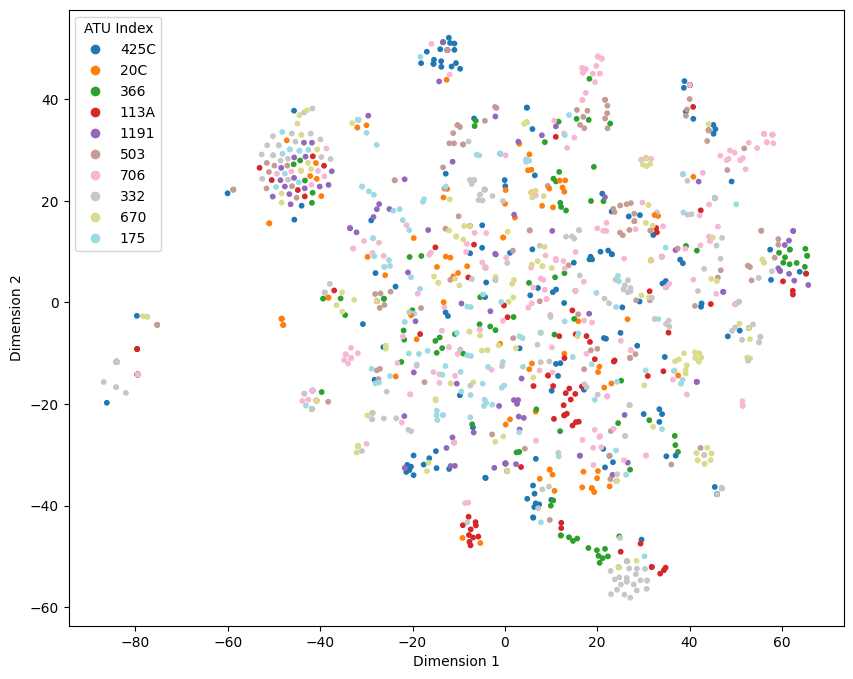

In [ ]:

#import mplcursors
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

flat_sentences = []
atu_indices = []
for index, row in expanded_df.iterrows():
    sentence = row["motif_list_clustered"]
    flat_sentences.append(sentence)
    atu_indices.append(row["atu_id"])

all_embeddings = np.vstack(expanded_df["motif_embeddings_clustered"].values)
#np.vstack(filtered_df["Sentence_Embeddings"].values)
from sklearn.decomposition import PCA
pca = PCA(n_components=50)
all_embeddings = pca.fit_transform(all_embeddings)

tsne = TSNE(n_components=2, random_state=42)
reduced_embeddings = tsne.fit_transform(all_embeddings)
expanded_df['TSNE_X'] = reduced_embeddings[:, 0]
expanded_df['TSNE_Y'] = reduced_embeddings[:, 1]


unique_atu_indices = expanded_df["atu_id"].unique()

colors_map = plt.cm.get_cmap('tab20', len(unique_atu_indices))

atu_color_dict = {atu: colors_map(i / len(unique_atu_indices)) for i, atu in enumerate(unique_atu_indices)}


point_colors = [atu_color_dict[atu] for atu in atu_indices]


plt.figure(figsize=(10, 8))
scatter = plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=point_colors,  s=10)

legend_patches = [plt.Line2D([0], [0], marker='o', color='w', markersize=8,
                             markerfacecolor=atu_color_dict[atu], label=f"{atu}")
                  for atu in unique_atu_indices]
plt.legend(handles=legend_patches, title="ATU Index", loc="best")


plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.show()


In [ ]:
len(temp_df["motif_embeddings"].iloc[0])

6

In [ ]:
index_of_stories_with_zero_motif=[]
for i in range(len(df)):
  l = len(df["motif_embeddings"].iloc[i])
  if l == 0:
    index_of_stories_with_zero_motif.append(i)
print(len(index_of_stories_with_zero_motif))


1070


In [ ]:
df.iloc[1070]

,1070
atu_id,2250
tale_title,Mary Morey
provenance,USA
notes,Type 2271.
source,The Only True Mother Goose Melodies: An Exact ...
text,"About Mary Morey, About her brother, And now m..."
data_source,Ashliman's Folktexts
date_obtained,2021-03-10
extracted_motifs,Here are some motifs that can be extracted fro...
text_motifs,Here are some motifs that can be extracted fro...


In [ ]:
temp_df['text_motifs'].iloc[95]

'Here are some motifs that can be extracted from the extremely short folktale \\'

In [ ]:
from itertools import combinations
def compare_motifs_across_atu(df):
    results = []
    for (atu1, group1), (atu2, group2) in combinations(df.groupby("atu_id"), 2):
        sentence_embeddings1 = np.vstack(group1["motif_embeddings"].values)
        sentence_embeddings2 = np.vstack(group2["motif_embeddings"].values)
        similarity_matrix = cosine_similarity(sentence_embeddings1, sentence_embeddings2)
        np.fill_diagonal(similarity_matrix, 0)
        max_sim_idx = np.unravel_index(np.argmax(similarity_matrix), similarity_matrix.shape)
        sentence1_idx, sentence2_idx = max_sim_idx

        results.append({
            "ATU_Index_1": atu1,
            "ATU_Index_2": atu2,
            "motif1": group1["motif_list_standardized"].iloc[sentence1_idx // len(group1["motif_list_standardized"].iloc[0])][sentence1_idx % len(group1["motif_list_standardized"].iloc[0])],
            "motif2": group2["motif_list_standardized"].iloc[sentence2_idx // len(group2["motif_list_standardized"].iloc[0])][sentence2_idx % len(group2["motif_list_standardized"].iloc[0])],
            "Similarity": similarity_matrix[sentence1_idx, sentence2_idx]
        })

    results = pd.DataFrame(results)

    results = results.sort_values(by="Similarity", ascending=False).reset_index(drop=True)
    return pd.DataFrame(results)

similarities_across_atu = compare_motifs_across_atu(df)
similarities_across_atu


IndexError: list index out of range

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer('all-MiniLM-L6-v2')


all_motifs = list(set([motif for motif_list in df['motif_list_standardized'] for motif in motif_list]))

motif_embeddings = model.encode(all_motifs, show_progress_bar=True)


similarity_matrix = cosine_similarity(motif_embeddings)

print(f"Similarity matrix shape: {similarity_matrix.shape}") 

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Batches:   0%|          | 0/285 [00:00<?, ?it/s]

Similarity matrix shape: (9116, 9116)


In [ ]:

similar_pairs = []
n_motifs = len(all_motifs)
for i in range(n_motifs):
    for j in range(i + 1, n_motifs):
        similarity = similarity_matrix[i, j]
        similar_pairs.append({
            'motif_1': all_motifs[i],
            'motif_2': all_motifs[j],
            'similarity': similarity
        })


similar_pairs_df = pd.DataFrame(similar_pairs)
similar_pairs_df = similar_pairs_df.sort_values(by='similarity', ascending=False)

print("Top 20 most similar motif pairs:")
print(similar_pairs_df.head(20))